In [1]:
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib import rcParams
from sklearn.decomposition import PCA
import umap
from scipy.stats import zscore

In [2]:
# Define the RGB codes
rgb_codes = [(152, 205, 168),
             (219,96,84)]

# Convert RGB codes to color strings
colors = ['#%02x%02x%02x' % rgb for rgb in rgb_codes]
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Baskerville']

In [3]:
def barplot_annotate_brackets(num1, num2, data, center, height, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values.

    :param num1: number of left bar to put bracket over
    :param num2: number of right bar to put bracket over
    :param data: string to write or number for generating asterixes
    :param center: centers of all bars (like plt.bar() input)
    :param height: heights of all bars (like plt.bar() input)
    :param yerr: yerrs of all bars (like plt.bar() input)
    :param dh: height offset over bar / bar + yerr in axes coordinates (0 to 1)
    :param barh: bar height in axes coordinates (0 to 1)
    :param fs: font size
    :param maxasterix: maximum number of asterixes to write (for very small p-values)
    """

    if type(data) is str:
        text = data
    else:
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # etc.
        text = ''
        p = .05

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    plt.plot(barx, bary, c='black', linewidth=0.75)

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    plt.text(*mid, text, **kwargs)

In [4]:
def perform_t_test(df, measure, num_column):
    """
    Perform t-tests between pairs of unique categories based on a numeric column.

    Parameters:
    - df: DataFrame containing the data
    - measure: Name of the numeric column for which t-tests will be performed
    - num_column: Name of the column containing the categories

    Returns:
    - t_stat_dict: Dictionary containing t-statistics for each pair of categories
    - p_value_dict: Dictionary containing p-values for each pair of categories
    """

    # Get unique categories
    unique_categories = df[num_column].unique()

    # Initialize dictionaries to store t-statistics and p-values
    t_stat_dict = {}
    p_value_dict = {}

    # Iterate through unique categories and perform t-test for each pair
    for i in range(len(unique_categories)):
        for j in range(i+1, len(unique_categories)):
            cat1 = unique_categories[i]
            cat2 = unique_categories[j]

            # Extract data for each category
            data_cat1 = df[df[num_column] == cat1][measure]
            data_cat2 = df[df[num_column] == cat2][measure]

            # Perform t-test
            t_stat, p_value = stats.ttest_ind(data_cat1, data_cat2, permutations=1000, equal_var=False)
            #print(cat1,cat2,p_value)

            # Store results in dictionaries
            key = f"{cat1}_{cat2}"
            t_stat_dict[key] = t_stat
            p_value_dict[key] = p_value

    return t_stat_dict, p_value_dict




In [5]:
## Load data
data_dir = "/Users/behnaz/NCADD/hIPSC/Fluo_pipeline/graph_fingerprint/Raw_traces/DF/abs(FC)_Raw_traces_before_Glut_CTL_SZ_Normal_hIPSC_graph_measures.csv"
save_path = "/Users/behnaz/NCADD/hIPSC/Fluo_pipeline/graph_fingerprint/FC_adj_mat/figs/"
df = pd.read_csv(data_dir)
df

,Unnamed: 0,Assortativity,Average clustering coefficient,Average shortest path length,Average square clustering,Degree (min),Degree (max),Degree (avg),Degree (std),Degree (med),...,Node strength (max),Node strength (avg),Node strength (std),Node strength (med),Rich club coefficient (min),Rich club coefficient (max),Rich club coefficient (avg),Rich club coefficient (std),Rich club coefficient (med),Transitivity
0,signf_corr_before_Glut_Test2_Week_6_2022_08_25...,0.604811,0.588863,0.335350,0.627987,0.0,0.712513,0.621577,0.736646,0.521482,...,0.312225,0.366011,0.381367,0.320169,0.631233,1.000000,0.443401,0.381883,0.285726,0.762117
1,signf_corr_before_Glut_Test2_Week_2_2022_08_03...,0.726799,0.171411,0.164383,0.159700,0.0,0.243206,0.186486,0.222601,0.129975,...,0.244658,0.161693,0.199798,0.111423,0.251136,1.000000,0.343768,0.608146,0.183437,0.281916
2,signf_corr_before_Glut_Test2_Week_2_2022_09_02...,0.606132,0.353053,0.009000,0.260494,0.0,0.416523,0.259690,0.288086,0.200504,...,0.544552,0.363994,0.420702,0.259515,0.297563,1.000000,0.351719,0.602140,0.201904,0.311743
3,signf_corr_before_Glut_Test2_Week_2_2022_09_01...,0.211955,0.702651,0.015617,0.663740,0.0,0.741298,0.416101,0.652144,0.279959,...,1.000000,0.693947,1.000000,0.452204,0.459765,0.113477,0.359325,0.056919,0.335431,0.577196
4,signf_corr_before_Glut_Test2_Week_6_2022_09_30...,0.754382,0.070538,0.410548,0.024163,0.0,0.282558,0.073095,0.093957,0.051872,...,0.187105,0.032404,0.052939,0.028601,0.156421,1.000000,0.719910,0.913237,0.675152,0.151787
5,signf_corr_before_Glut_Test2_Week_2_2022_09_02...,0.621302,0.154368,0.307804,0.022276,0.0,0.052808,0.043430,0.000000,0.043028,...,0.093009,0.034833,0.024426,0.037419,0.000000,0.016393,0.050194,0.234089,0.017029,0.027173
6,signf_corr_before_Glut_Test2_Week_6_2022_08_25...,0.606106,0.581504,0.139994,0.581516,0.0,0.631944,0.479365,0.647923,0.334173,...,0.507988,0.467485,0.588412,0.290126,0.509168,1.000000,0.466277,0.468079,0.284902,0.721827
7,signf_corr_before_Glut_Test2_Week_2_2022_08_05...,0.856274,0.247506,0.165064,0.145018,0.0,0.215062,0.139728,0.181487,0.090676,...,0.286076,0.158290,0.241210,0.089412,0.205438,1.000000,0.498313,0.765142,0.313477,0.330362
8,signf_corr_before_Glut_Test2_Week_6_2022_09_27...,0.385691,0.278456,0.104470,0.188998,0.0,0.616333,0.112296,0.308792,0.037291,...,0.733893,0.166858,0.441173,0.045905,0.224881,1.000000,0.967057,0.770010,0.870053,0.192120
9,signf_corr_before_Glut_Test2_Week_2_2022_09_02...,0.874200,0.326870,0.190786,0.221995,0.0,0.289586,0.162259,0.190839,0.109280,...,0.330766,0.180966,0.246328,0.112770,0.230937,1.000000,0.487290,0.814387,0.271833,0.420309


In [6]:
all_columns = df.columns.tolist()
all_columns 

['Unnamed: 0',
 'Assortativity',
 'Average clustering coefficient',
 'Average shortest path length',
 'Average square clustering',
 'Degree (min)',
 'Degree (max)',
 'Degree (avg)',
 'Degree (std)',
 'Degree (med)',
 'Density',
 'Edge betweenness centrality (min)',
 'Edge betweenness centrality (max)',
 'Edge betweenness centrality (avg)',
 'Edge betweenness centrality (std)',
 'Edge betweenness centrality (med)',
 'Eccentricity (min)',
 'Eccentricity (max)',
 'Eccentricity (avg)',
 'Eccentricity (std)',
 'Eccentricity (med)',
 'Fraction of nodes in the barycenter',
 'Fraction of nodes in the center',
 'Fraction of nodes in the periphery',
 'Global efficiency',
 'Local efficiency (min)',
 'Local efficiency (max)',
 'Local efficiency (avg)',
 'Local efficiency (std)',
 'Local efficiency (med)',
 'Modularity',
 'Node betweenness centrality (min)',
 'Node betweenness centrality (max)',
 'Node betweenness centrality (avg)',
 'Node betweenness centrality (std)',
 'Node betweenness centralit

In [7]:

# # Columns to exclude from normalization
# exclude_columns = ['Unnamed: 0']

# # # Get all columns except those to exclude
# columns_to_normalize = [col for col in df.columns if col not in exclude_columns]

# # # Apply z-score normalization to the specified columns
# df[columns_to_normalize] = df[columns_to_normalize].apply(zscore)

# # Calculate the correlation matrix on the remaining columns, excluding 'Label'
# df_numeric = df.drop(columns=exclude_columns)
# correlation_matrix = df_numeric.corr()

# # If you want to exclude more columns for normalization and correlation calculation:
# # exclude_columns = ['Label', 'other_column1', 'other_column2']


In [8]:


# Replace 0 with 1 for rows containing 'SZ' in the column name
df.loc[df['Unnamed: 0'].str.contains('CTL'), 'numeric_category'] = 0
df.loc[df['Unnamed: 0'].str.contains('SZ'), 'numeric_category'] = 1
# Sort the DataFrame by 'numeric_category'
df = df.sort_values(by='numeric_category')

# Calculate the correlation matrix on the remaining columns, excluding 'Label'
df_numeric = df.drop(columns='Unnamed: 0')

## Significant p_values

In [9]:
# Assuming all_columns is defined somewhere in the code
all_columns = df.columns.difference(['Unnamed: 0', 'numeric_category'])

# Iterate through all columns and perform t-tests
for i in all_columns:
    t_stat_dict, p_value_dict = perform_t_test(df, i, 'numeric_category')

    # Print the t-statistics and p-values for each pair where p < 0.05
    for key in p_value_dict:
        p_value = p_value_dict[key]
        if p_value < 0.05 and not np.isnan(p_value):
            print(f"Significant result for {i}: t_stat_{key} = {t_stat_dict[key]}, p_value_{key} = {p_value}")


Significant result for Edge betweenness centrality (med): t_stat_0.0_1.0 = 1.9009240958022013, p_value_0.0_1.0 = 0.04895104895104895
Significant result for Global efficiency: t_stat_0.0_1.0 = -3.0466957304667166, p_value_0.0_1.0 = 0.004995004995004995
Significant result for Local efficiency (avg): t_stat_0.0_1.0 = -3.2334444500075334, p_value_0.0_1.0 = 0.003996003996003996
Significant result for Local efficiency (med): t_stat_0.0_1.0 = -2.6827942970610743, p_value_0.0_1.0 = 0.011988011988011988
Significant result for Local efficiency (std): t_stat_0.0_1.0 = 2.371112200990853, p_value_0.0_1.0 = 0.022977022977022976
Significant result for Node betweenness centrality (med): t_stat_0.0_1.0 = 2.36494979482683, p_value_0.0_1.0 = 0.015984015984015984
Significant result for Rich club coefficient (avg): t_stat_0.0_1.0 = 3.0707945099474068, p_value_0.0_1.0 = 0.004995004995004995
Significant result for Rich club coefficient (med): t_stat_0.0_1.0 = 3.0548977655366256, p_value_0.0_1.0 = 0.005994005

/Users/behnaz/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:7593: RuntimeWarning: invalid value encountered in scalar divide
  return (avg_a-avg_b)/denom
/Users/behnaz/miniconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:7593: RuntimeWarning: invalid value encountered in divide
  return (avg_a-avg_b)/denom


{'0.0_1.0': 0.013986013986013986}


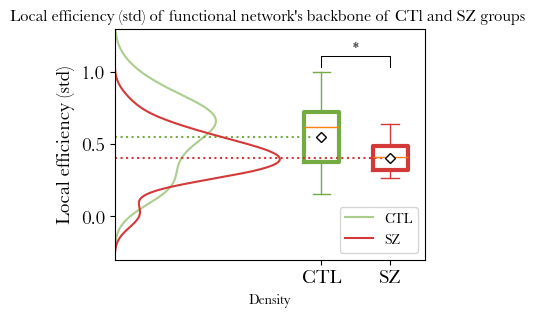

In [23]:
cat = 'Local efficiency (std)'

# Define the RGB codes
rgb_codes = [(116, 172, 67), (212, 57, 57)]

# Convert RGB codes to color strings
colors = ['#%02x%02x%02x' % rgb for rgb in rgb_codes]

# Compute mean values for CTL and SZ groups
meanctl = np.mean(df.loc[df['numeric_category'] == 0, cat])
meansz = np.mean(df.loc[df['numeric_category'] == 1, cat])

# Create the box plot
fig, ax = plt.subplots(figsize=(4, 3))

# Define properties for CTL boxplot
boxprops_ctl = dict(linestyle='-', linewidth=3, color=colors[0])
whiskerprops_ctl = dict(color=colors[0])
capprops_ctl = dict(color=colors[0])
meanprops_ctl = dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=5)

# Define properties for SZ boxplot
boxprops_sz = dict(linestyle='-', linewidth=3, color=colors[1])
whiskerprops_sz = dict(color=colors[1])
capprops_sz = dict(color=colors[1])
meanprops_sz = dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=5)

# Extract data for CTL and SZ groups
all_values_ctl = df.loc[df['numeric_category'] == 0, cat]
all_values_sz = df.loc[df['numeric_category'] == 1, cat]

# Plot boxplot for CTL
ax.boxplot(all_values_ctl, positions=[3], labels=['CTL'], showfliers=False,
           boxprops=boxprops_ctl, showmeans=True, meanprops=meanprops_ctl,
           whiskerprops=whiskerprops_ctl, capprops=capprops_ctl, widths=(0.51))

# Plot boxplot for SZ
ax.boxplot(all_values_sz, positions=[4], labels=['SZ'], showfliers=False, showmeans=True,
           meanprops=meanprops_sz, boxprops=boxprops_sz, whiskerprops=whiskerprops_sz,
           capprops=capprops_sz, widths=(0.51))

# Set y-axis limit
ax.set_ylim(-0.3, 1.3)
ax.set_xlim(0, 4.5)

# Add vertical distribution plot on the right side for CTL
ax1 = sns.kdeplot(y=all_values_ctl, color=colors[0], ax=ax,
                  label="CTL",
                  fill=False, alpha=0.6, common_norm=True)
kdeline1 = ax1.lines[0]
x1 = kdeline1.get_xdata()
y1 = kdeline1.get_ydata()
height1 = np.interp(meanctl, x1, y1 + 2.5)
ax1.hlines(meanctl, 0, height1, color=colors[0], ls=':')

# Add vertical distribution plot on the right side for SZ
ax2 = sns.kdeplot(y=all_values_sz, color=colors[1], ax=ax,
                  label="SZ",
                  fill=False, common_norm=True)
kdeline2 = ax2.lines[0]
x2 = kdeline2.get_xdata()
y2 = kdeline2.get_ydata()
height2 = np.interp(meansz, x2, y2 + 3.5)
ax2.hlines(meansz, 0, height2, color=colors[1], ls=':')


t_stat_dict, p_value_dict = perform_t_test(df, cat, 'numeric_category')
print(p_value_dict)
# Annotate the brackets with p-values
heights = [0.9,0.6,0.9,1,1,1,1,1,1]
bars = np.arange(len(heights))+1
barplot_annotate_brackets(2, 3, p_value_dict['0.0_1.0'], bars, heights, dh=0.02)
ax.tick_params(axis='both', labelsize=14)

# Show the plot
plt.title(f"{cat} of functional network's backbone of CTl and SZ groups ")
plt.ylabel(f'{cat}', fontsize=14)
plt.legend()
plt.savefig(save_path+cat+'.svg')
plt.show()


In [191]:
# Calculate the correlation matrix on the remaining columns, excluding 'Label'
df_numeric = df.drop(columns='numeric_category')
df_numeric = df_numeric.drop(columns='Unnamed: 0')

In [199]:

# selected_columns = [
#     'Global efficiency',
#     'Rich club coefficient (avg)',
#     'Rich club coefficient (med)',
#     'Rich club coefficient (std)',
#     'Node strength (avg)',
#     'Node betweenness centrality (med)',
#     'numeric_category'
# ]
selected_columns = [
    'Global efficiency',
    'numeric_category'
]


# Select the relevant columns
df_selected = df[selected_columns]

# Replace NaN values with zero in df_selected
#df_selected = df_selected.fillna(0)

df_selected_numeric = df_selected.drop(columns=['numeric_category'])


PCA variance ratio: [0.89263441 0.10736559]


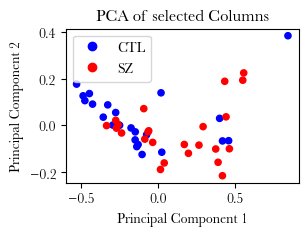

In [196]:

# # Apply PCA

pca = PCA(n_components=2)
pca.fit((df_selected_numeric))

print('PCA variance ratio:',pca.explained_variance_ratio_)

plt.figure(figsize=(3, 2))
X_pca = pca.transform(df_selected_numeric)
scatter = plt.scatter(X_pca[:,0], X_pca[:,1],s=20,c = df_selected['numeric_category'].values,cmap='bwr')


# Add a legend
handles, labels = scatter.legend_elements()
legend_labels = ['CTL', 'SZ']
plt.legend(handles, legend_labels)

# Add labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of selected Columns')

# Show the plot
plt.show()



# fig = plt.figure(figsize=(3, 3))
# ax = fig.add_subplot(projection='3d')
# ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c=df_selected['numeric_category'].values,s=20,cmap='bwr')
# plt.show()

/Users/behnaz/miniconda3/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


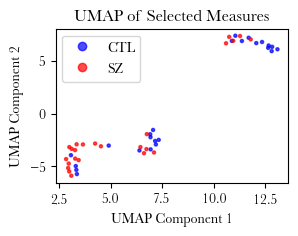

In [204]:


# Apply UMAP
umap_model = umap.UMAP(n_neighbors=13, min_dist=0.1,n_components=2, random_state=100)
u = umap_model.fit_transform(df_selected_numeric)
umap1 = u[:, 0] # first UMAP axis
umap2 = u[:, 1] # second UMAP axis
plt.figure(figsize=(3,2))
scatter =plt.scatter(u[:,0], u[:,1], c = df_selected['numeric_category'].values, s=5.0 , cmap='bwr', alpha=0.7)
plt.title('UMAP embedding')
# Add a legend
handles, labels = scatter.legend_elements()
legend_labels = ['CTL', 'SZ']
plt.legend(handles, legend_labels)

# Add labels and title
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.title('UMAP of Selected Measures')

# Show the plot
plt.show()

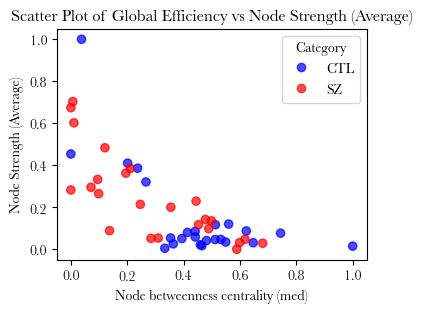

In [175]:
# Plotting
plt.figure(figsize=(4, 3))
scatter = plt.scatter(df['Node betweenness centrality (med)'], df['Node strength (avg)'], 
                      c=df['numeric_category'], cmap='bwr', alpha=0.7)

# Add a legend
handles, labels = scatter.legend_elements()
legend_labels = ['CTL', 'SZ']
plt.legend(handles, legend_labels, title="Category")

# Add labels and title
plt.xlabel('Node betweenness centrality (med)')
plt.ylabel('Node Strength (Average)')
plt.title('Scatter Plot of Global Efficiency vs Node Strength (Average)')

# Show the plot
plt.show()

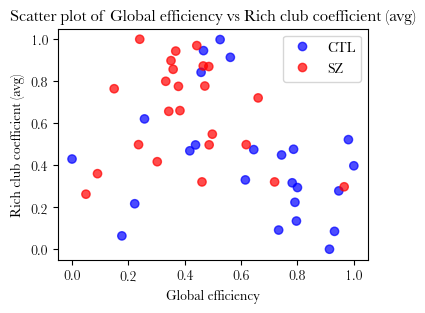

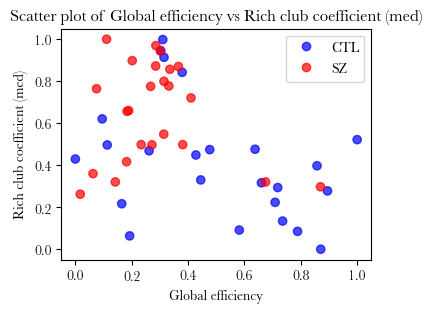

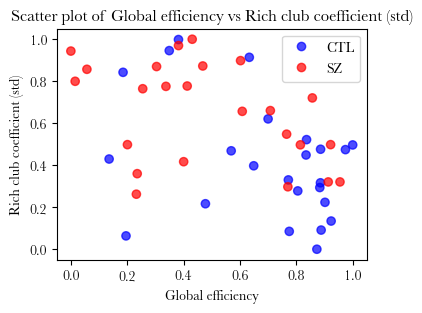

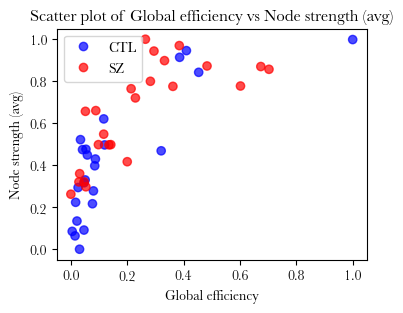

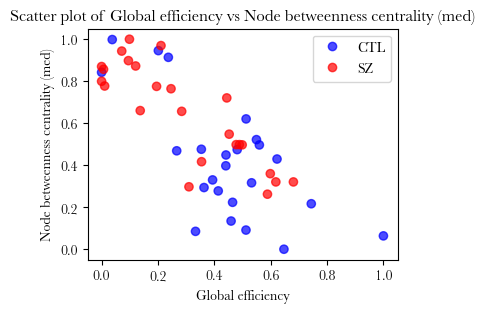

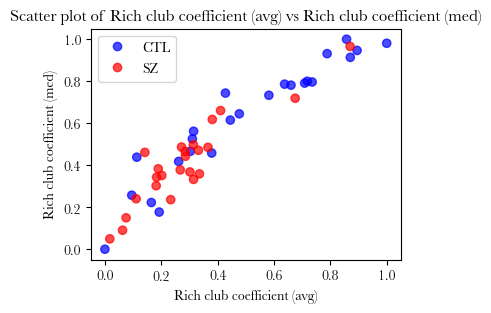

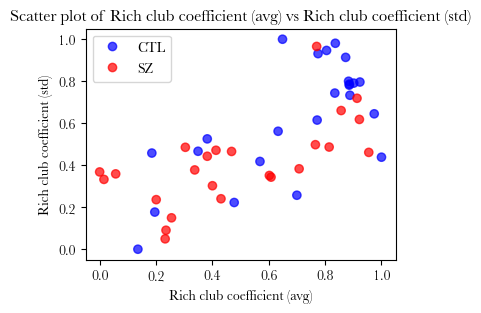

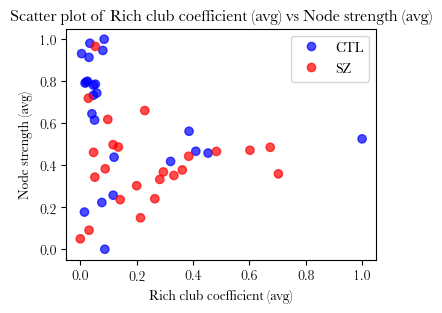

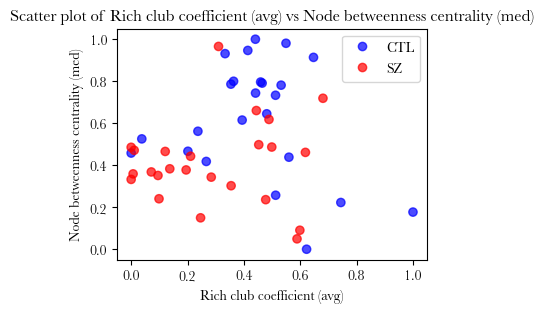

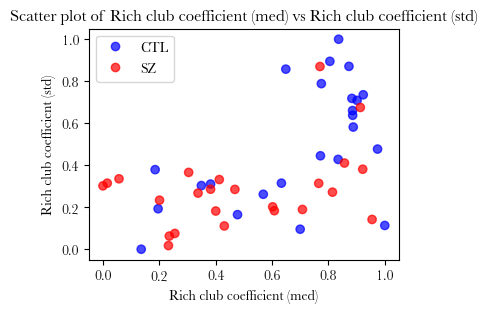

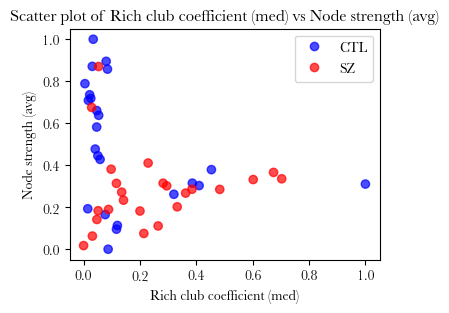

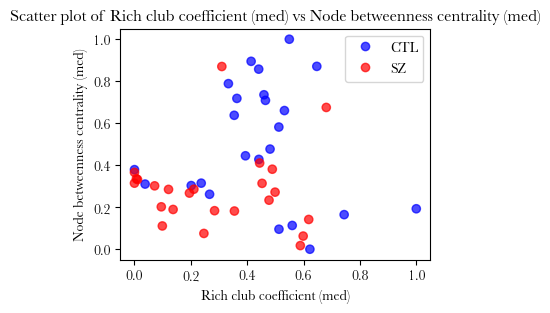

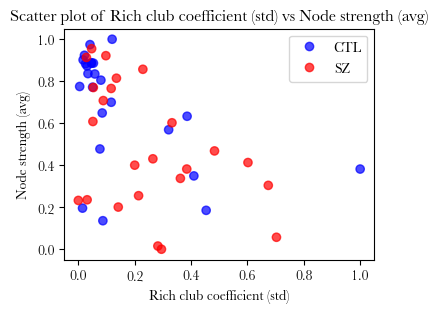

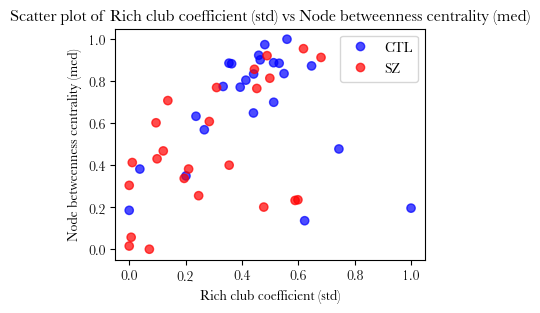

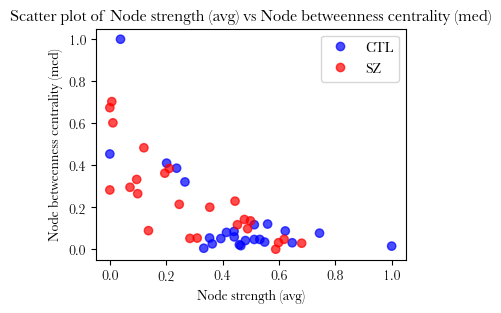

In [176]:
# Specify the measures to use for UMAP
selected_columns = [
    'Global efficiency',
    'Rich club coefficient (avg)',
    'Rich club coefficient (med)',
    'Rich club coefficient (std)',
    'Node strength (avg)',
    'Node betweenness centrality (med)'
]
# Plot each pair of columns
for i in range(len(selected_columns )):
    for j in range(i + 1, len(selected_columns )):
        x_col = selected_columns [i]
        y_col = selected_columns [j]

        plt.figure(figsize=(4, 3))
        scatter = plt.scatter( df_numeric[y_col],df_numeric[x_col], c=df['numeric_category'], cmap='bwr', alpha=0.7)

        # Add a legend
        handles, labels = scatter.legend_elements()
        legend_labels = ['CTL', 'SZ']
        plt.legend(handles, legend_labels)

        # Add labels and title
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.title(f'Scatter plot of {x_col} vs {y_col}')

        # Show the plot
        plt.show()


{'0.0_1.0': 0.04995004995004995}


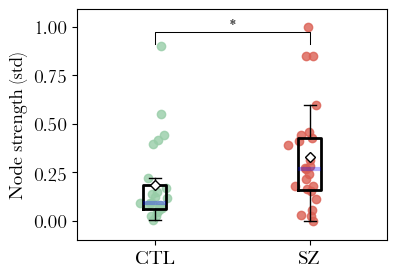

In [30]:


def plot_boxplot(df, measure, num_cat):
    """
    Plot boxplot of numeric column across numeric categories.

    Parameters:
    - df: DataFrame containing the data
    - measure: Name of the numeric column for which boxplot will be plotted
    - num_cat: Name of the column containing the numeric categories
    """
    
    t_stat_dict, p_value_dict = perform_t_test(df, measure, num_cat)
    print(p_value_dict)
    
    
    # Group the DataFrame by the numeric category
    grouped = df.groupby(num_cat)

    names, vals, xs = [], [], []

    for i, (name, subdf) in enumerate(grouped):
        names.append(name)
        vals.append(subdf[measure].tolist())
        xs.append(np.random.normal(i + 1, 0.04, subdf.shape[0]))
    # Create labels with 'DIV' appended to each name
    
    labels_with_div = [str(name) + '' for name in names]

    # Create the boxplot
    fig, ax = plt.subplots(figsize=(4, 3))
    
    medianprops = dict(linestyle='-', linewidth=3, color='blue',alpha=0.3) #{'color': '#1c77c3'}
    boxprops = dict(linestyle='-', linewidth=2, color='black')
    plt.boxplot(vals, labels=['CTL', 'SZ'],showfliers=False,boxprops=boxprops,medianprops=medianprops,
                 showmeans=True,meanprops={"marker":"D", "markerfacecolor":"white", 
                      "markeredgecolor":"black",
                      "markersize":"5"})

    # Scatter plot with different colors for each group
    for x, val, color in zip(xs, vals, colors):
        plt.scatter(x, val, color=color, alpha=0.8)
    ax.set_ylim(-0.1+np.min(df[measure]),np.max(df[measure])+0.09*np.max(df[measure]))    
        
  
    # Annotate the brackets with p-values
    heights = [0.9*np.max(df[measure]),0.6*np.max(df[measure]),0.9*np.max(df[measure]),np.max(df[measure])]
    bars = np.arange(len(heights))+1
    barplot_annotate_brackets(0, 1, p_value_dict['0.0_1.0'], bars, heights, dh=0.01)

    # Add labels and title
    #plt.xlabel(num_cat,fontsize=18)
    measure_label = ' '.join(measure.split('_'))
    plt.ylabel( measure_label,fontsize=14)
    #plt.title(f'{measure}')
    ax.tick_params(axis='both', labelsize=14)
    # Add text labels beside each numeric category
    #plt.savefig(f'{measure}.svg')
    #plt.savefig(save_path+cat+'.svg')
    plt.show()

cat = 'Node strength (std)'
plot_boxplot(df, cat, 'numeric_category')

